# Rides Data EDA

In [233]:
import sys
from pathlib import Path
from unicodedata import category

import pandas as pd

sys.path.append(str(Path("..")))

from scripts.utils import load_raw_file

In [234]:
df = load_raw_file('JC-201601-citibike-tripdata.csv')

## Data Structure

In [235]:
df.head()

,Trip Duration,Start Time,Stop Time,Start Station ID,Start Station Name,Start Station Latitude,Start Station Longitude,End Station ID,End Station Name,End Station Latitude,End Station Longitude,Bike ID,User Type,Birth Year,Gender
0,362,2016-01-01 00:02:52,2016-01-01 00:08:54,3186,Grove St PATH,40.719586,-74.043117,3209,Brunswick St,40.724176,-74.050656,24647,Subscriber,1964.0,2
1,200,2016-01-01 00:18:22,2016-01-01 00:21:42,3186,Grove St PATH,40.719586,-74.043117,3213,Van Vorst Park,40.718489,-74.047727,24605,Subscriber,1962.0,1
2,202,2016-01-01 00:18:25,2016-01-01 00:21:47,3186,Grove St PATH,40.719586,-74.043117,3213,Van Vorst Park,40.718489,-74.047727,24689,Subscriber,1962.0,2
3,248,2016-01-01 00:23:13,2016-01-01 00:27:21,3209,Brunswick St,40.724176,-74.050656,3203,Hamilton Park,40.727596,-74.044247,24693,Subscriber,1984.0,1
4,903,2016-01-01 01:03:20,2016-01-01 01:18:24,3195,Sip Ave,40.730743,-74.063784,3210,Pershing Field,40.742677,-74.051789,24573,Customer,NaN,0


In [236]:
df.shape

(7479, 15)

In [237]:
df.describe()

,Trip Duration,Start Station ID,Start Station Latitude,Start Station Longitude,End Station ID,End Station Latitude,End Station Longitude,Bike ID,Birth Year,Gender
count,7.479000e+03,7479.000000,7479.000000,7479.000000,7479.000000,7479.000000,7479.000000,7479.000000,7177.000000,7479.000000
mean,8.760840e+02,3199.060035,40.723892,-74.046672,3196.959888,40.723235,-74.045822,24545.918171,1978.285356,1.155903
std,1.877094e+04,11.158335,0.007836,0.011177,32.764969,0.007745,0.011177,176.014069,9.688657,0.462590
min,6.100000e+01,3183.000000,40.697030,-74.096937,534.000000,40.697030,-74.096937,17941.000000,1941.000000,0.000000
25%,2.360000e+02,3186.000000,40.718489,-74.050656,3186.000000,40.718489,-74.050656,24454.000000,1973.000000,1.000000
50%,3.610000e+02,3199.000000,40.723659,-74.044247,3195.000000,40.721124,-74.043845,24559.000000,1980.000000,1.000000
75%,5.780000e+02,3209.000000,40.727596,-74.036486,3209.000000,40.727596,-74.036486,24640.000000,1985.000000,1.000000
max,1.569765e+06,3225.000000,40.752559,-74.032108,3225.000000,40.752559,-74.012723,24724.000000,1998.000000,2.000000


In [238]:
100 * df.isna().sum() / df.shape[0]

Trip Duration              0.000000
Start Time                 0.000000
Stop Time                  0.000000
Start Station ID           0.000000
Start Station Name         0.000000
Start Station Latitude     0.000000
Start Station Longitude    0.000000
End Station ID             0.000000
End Station Name           0.000000
End Station Latitude       0.000000
End Station Longitude      0.000000
Bike ID                    0.000000
User Type                  0.000000
Birth Year                 4.037973
Gender                     0.000000
dtype: float64

## Date/time Variables

In [239]:
df['Start Time'] = pd.to_datetime(df['Start Time'])
df['Stop Time'] = pd.to_datetime(df['Stop Time'])

In [240]:
# remove calculated field
df.drop('Trip Duration', axis=1, inplace=True)

In [241]:
print(df['Start Time'].min())
print(df['Start Time'].max())

2016-01-01 00:02:52
2016-01-31 23:55:36


## Stations data

In [242]:
df_start_stations = df[
	['Start Station ID', 'Start Station Name', 'Start Station Latitude', 'Start Station Longitude']]\
	.drop_duplicates()\
	.rename(
		{
			'Start Station ID': 'ID',
			'Start Station Name': 'Name',
			'Start Station Latitude': 'Latitude',
			'Start Station Longitude': 'Longitude'
	}, axis=1)

In [243]:
df_end_stations = df[
	['End Station ID', 'End Station Name', 'End Station Latitude', 'End Station Longitude']]\
	.drop_duplicates()\
	.rename(
		{
			'End Station ID': 'ID',
			'End Station Name': 'Name',
			'End Station Latitude': 'Latitude',
			'End Station Longitude': 'Longitude'
	}, axis=1)

In [244]:
df_stations = pd.concat([df_start_stations, df_end_stations], ignore_index=True)

In [245]:
df_stations.shape

(71, 4)

In [246]:
df.drop(
	['Start Station Name', 'Start Station Latitude', 'Start Station Longitude', 'End Station Name', 'End Station Latitude',
	 'End Station Longitude'], axis=1, inplace=True)

In [247]:
df.head()

,Start Time,Stop Time,Start Station ID,End Station ID,Bike ID,User Type,Birth Year,Gender
0,2016-01-01 00:02:52,2016-01-01 00:08:54,3186,3209,24647,Subscriber,1964.0,2
1,2016-01-01 00:18:22,2016-01-01 00:21:42,3186,3213,24605,Subscriber,1962.0,1
2,2016-01-01 00:18:25,2016-01-01 00:21:47,3186,3213,24689,Subscriber,1962.0,2
3,2016-01-01 00:23:13,2016-01-01 00:27:21,3209,3203,24693,Subscriber,1984.0,1
4,2016-01-01 01:03:20,2016-01-01 01:18:24,3195,3210,24573,Customer,NaN,0


## Visualsizations

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

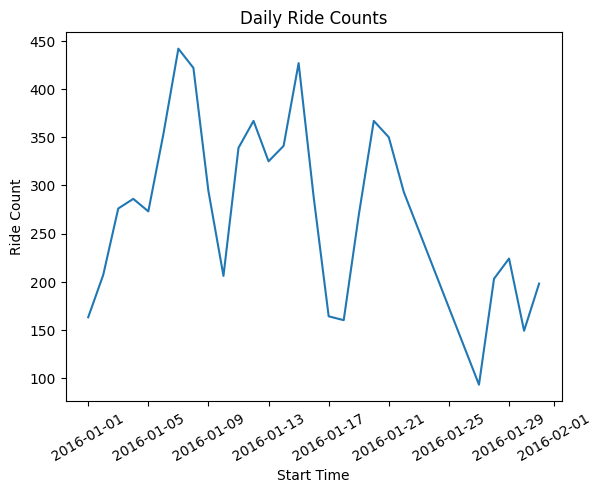

In [249]:
daily_ride_counts = df.groupby(df["Start Time"].dt.date, as_index=False).size().rename({'size': 'Ride Count'}, axis=1)

ax = sns.lineplot(data=daily_ride_counts, x='Start Time', y='Ride Count')
ax.set_title('Daily Ride Counts')
ax.tick_params(axis='x', rotation=30)
plt.show()

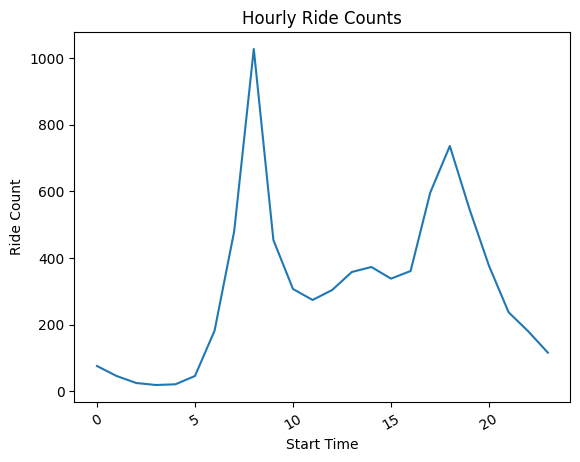

In [250]:
hourly_ride_counts = df.groupby(df["Start Time"].dt.hour, as_index=False).size().rename({'size': 'Ride Count'}, axis=1)

ax = sns.lineplot(data=hourly_ride_counts, x='Start Time', y='Ride Count')
ax.set_title('Hourly Ride Counts')
ax.tick_params(axis='x', rotation=30)
plt.show()

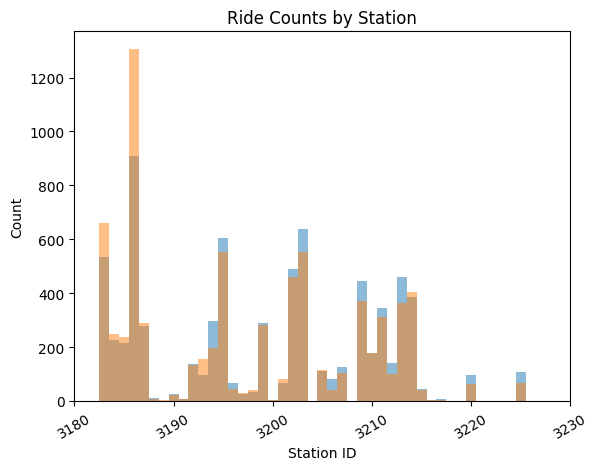

In [267]:
ax = sns.histplot(data=df, x='Start Station ID', discrete=True, alpha=.5, linewidth=0)
sns.histplot(data=df, x='End Station ID', discrete=True, alpha=.5, linewidth=0)
ax.set_title('Ride Counts by Station')
ax.set_xlabel('Station ID')
ax.tick_params(axis='x', rotation=30)
ax.set_xlim(3180, 3230)
plt.show()